# Spectral Clustering (Clustering Espectral)

## ¿Qué es?

Usa la estructura de **valores y vectores propios** (espectro) de una matriz de similitud entre los datos.

Idea intuitiva:
1. Construye un grafo donde los nodos son puntos y las aristas son similitud
2. Calcula vectores propios del grafo (Laplaciana)
3. Aplica K-means sobre estos vectores propios transformados

Ideal para datos con formas complejas que no son linealmente separables.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_circles
from sklearn.cluster import SpectralClustering, KMeans
from sklearn.preprocessing import StandardScaler

%matplotlib inline


## Ejemplo 1: make_circles (círculos concéntricos)

Este dataset es un clásico para mostrar las limitaciones de K-means.


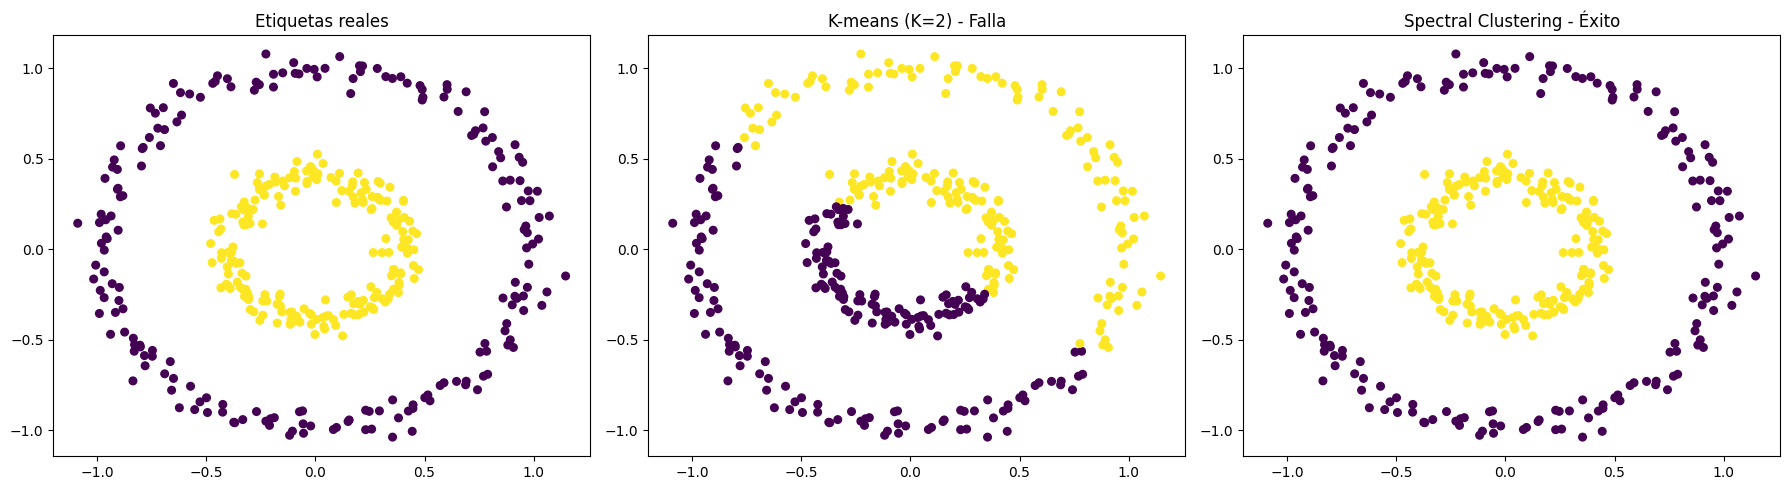

In [2]:
X, y_true = make_circles(n_samples=400, factor=0.4, noise=0.05, random_state=42)
X_scaled = StandardScaler().fit_transform(X)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

ax1.scatter(X[:, 0], X[:, 1], c=y_true, cmap='viridis', s=30)
ax1.set_title('Etiquetas reales')

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_km = kmeans.fit_predict(X_scaled)
ax2.scatter(X[:, 0], X[:, 1], c=labels_km, cmap='viridis', s=30)
ax2.set_title('K-means (K=2) - Falla')

spectral = SpectralClustering(n_clusters=2, affinity='rbf', gamma=15, random_state=42, assign_labels='kmeans')
labels_sc = spectral.fit_predict(X_scaled)
ax3.scatter(X[:, 0], X[:, 1], c=labels_sc, cmap='viridis', s=30)
ax3.set_title('Spectral Clustering - Éxito')

plt.tight_layout()
plt.show()


## Ejemplo 2: make_moons


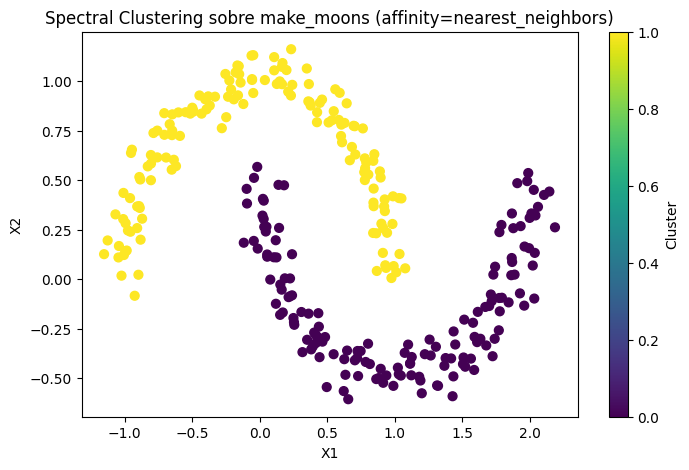

In [3]:
X, y_true = make_moons(n_samples=300, noise=0.07, random_state=42)
X_scaled = StandardScaler().fit_transform(X)

spectral = SpectralClustering(n_clusters=2, affinity='nearest_neighbors', n_neighbors=10, random_state=42)
labels = spectral.fit_predict(X_scaled)

plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=40)
plt.title('Spectral Clustering sobre make_moons (affinity=nearest_neighbors)')
plt.xlabel('X1'); plt.ylabel('X2')
plt.colorbar(label='Cluster')
plt.show()


## Parámetro affinity y gamma

Dos formas comunes de construir la matriz de afinidad:
- **rbf (Radial Basis Function)**: depende de `gamma` (ancho del kernel). Valores grandes = clusters locales.
- **nearest_neighbors**: conecta cada punto con sus K vecinos. Más robusto a escala.


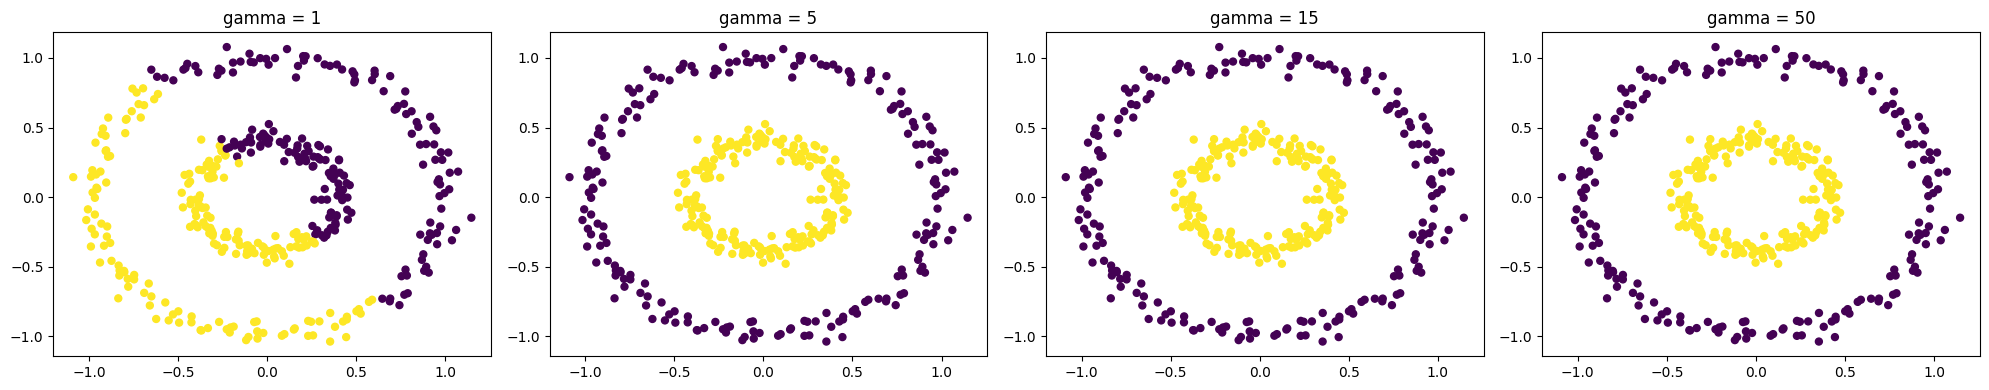

In [4]:
X, _ = make_circles(n_samples=400, factor=0.4, noise=0.05, random_state=42)
X_scaled = StandardScaler().fit_transform(X)

gamma_vals = [1, 5, 15, 50]
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for i, g in enumerate(gamma_vals):
    sc = SpectralClustering(n_clusters=2, affinity='rbf', gamma=g, random_state=42)
    lbls = sc.fit_predict(X_scaled)
    axes[i].scatter(X[:, 0], X[:, 1], c=lbls, cmap='viridis', s=25)
    axes[i].set_title(f'gamma = {g}')
plt.tight_layout()
plt.show()


## Resumen

| Ventaja | Desventaja |
|---|---|
Formas de clusters arbitrarias | Requiere K de antemano |
Funciona con datos no lineales | Escala mal con grandes datasets |
Menos dependiente de convexidad | Ajuste de gamma / n_neighbors |
